Module 2 - Phase 1: Dataset Preparation
Objective

Before training any model, we need to answer these questions:

What is our target variable?
What are our input features?
Is the target balanced?
Do we need preprocessing?
Are there missing values?
Which features should we keep?


modules/
└── Module_02_Loan_Prediction/
    ├── notebook/
    │   └── 02_Loan_Prediction.ipynb
    ├── reports/
    ├── visuals/
    ├── models/
    ├── processed_data/
    └── README.md

In [1]:
# ==========================================================
# Module 2 : Loan Approval Prediction
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
master = pd.read_csv(
    "/home/student/Documents/308/mlm/AI-Banking-Financial-Intelligence-Platform/datasets/processed_data/master_dataset.csv"
)

loans = pd.read_csv(
    "/home/student/Documents/308/mlm/AI-Banking-Financial-Intelligence-Platform/datasets/raw/loans.csv"
)

loan_status = pd.read_csv(
    "/home/student/Documents/308/mlm/AI-Banking-Financial-Intelligence-Platform/datasets/raw/loan_statuses.csv"
)

print(master.shape)
print(loans.shape)
print(loan_status.shape)

(2001, 21)
(333, 7)
(3, 2)


In [4]:
loans.head(5)

,LoanID,AccountID,LoanStatusID,PrincipalAmount,InterestRate,StartDate,EstimatedEndDate
0,400230,200876,1,76958.56,0.0547,2022-11-20 00:00:00.000000,2026-08-06 00:00:00.000000
1,400307,200789,1,29013.67,0.0321,2022-02-22 00:00:00.000000,2025-12-08 00:00:00.000000
2,400233,201275,1,48596.76,0.1017,2021-11-21 00:00:00.000000,2023-07-30 00:00:00.000000
3,400100,200070,1,9191.43,0.0999,2021-08-14 00:00:00.000000,2023-09-18 00:00:00.000000
4,400141,200808,1,76322.83,0.0906,2021-06-04 00:00:00.000000,2024-10-23 00:00:00.000000


In [5]:
loans.info()

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   LoanID            333 non-null    int64  
 1   AccountID         333 non-null    int64  
 2   LoanStatusID      333 non-null    int64  
 3   PrincipalAmount   333 non-null    float64
 4   InterestRate      333 non-null    float64
 5   StartDate         327 non-null    str    
 6   EstimatedEndDate  327 non-null    str    
dtypes: float64(2), int64(3), str(2)
memory usage: 18.3 KB


In [6]:
loan_status


,LoanStatusID,StatusName
0,1,Active
1,2,Paid Off
2,3,Overdue


In [8]:
loans['LoanStatusID'].value_counts()

LoanStatusID
1    242
2     57
3     34
Name: count, dtype: int64

In [11]:
loan_data=loans.merge(loan_status,on="LoanStatusID",how="left")
loan_data.head

<bound method NDFrame.head of      LoanID  AccountID  LoanStatusID  PrincipalAmount  InterestRate  \
0    400230     200876             1         76958.56        0.0547   
1    400307     200789             1         29013.67        0.0321   
2    400233     201275             1         48596.76        0.1017   
3    400100     200070             1          9191.43        0.0999   
4    400141     200808             1         76322.83        0.0906   
..      ...        ...           ...              ...           ...   
328  400008     200379             1         47534.75        0.1395   
329  400091     201053             1         47644.19        0.0822   
330  400288     201275             2         34024.66        0.0476   
331  400056     200691             1         65871.54        0.1185   
332  400212     200447             1         89845.11        0.1394   

                      StartDate            EstimatedEndDate StatusName  
0    2022-11-20 00:00:00.000000  2026-08-06 

In [12]:
loan_data["StatusName"].value_counts()

StatusName
Active      242
Paid Off     57
Overdue      34
Name: count, dtype: int64

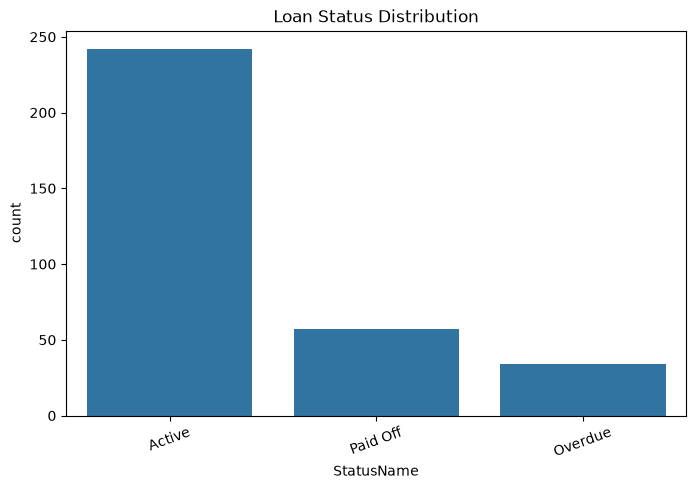

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=loan_data,
    x="StatusName"
)

plt.title("Loan Status Distribution")

plt.xticks(rotation=20)

plt.show()

In [14]:
loan_data["StatusName"].value_counts(normalize=True) * 100

StatusName
Active      72.672673
Paid Off    17.117117
Overdue     10.210210
Name: proportion, dtype: float64

Feature Selection & ML Dataset Preparation



Our goal is not to train the model immediately.

Our goal is to create the perfect dataset for machine learning.

Think of it like preparing ingredients before cooking.

Raw Banking Tables
        │
        ▼
Module 1
(Data Cleaning + EDA)
        │
        ▼
Master Dataset
        │
        ▼
Loan Dataset
        │
        ▼
Merge Datasets
        │
        ▼
Feature Selection
        │
        ▼
Feature Engineering
        │
        ▼
Encoding
        │
        ▼
Train/Test Split
        │
        ▼
Decision Tree

In [16]:
loan_master=master.merge(loans,on="AccountID",how="inner")

loan_master.head()

,CustomerID,FirstName,LastName,DateOfBirth,AddressID,CustomerTypeID,Street,City,Country,CustomerType,...,LoanStatus,OpeningYear,age,AccountAge,LoanID,LoanStatusID,PrincipalAmount,InterestRate,StartDate,EstimatedEndDate
0,10964,Jewell,Flowers,1978-05-31 00:00:00.000000,700,3,Newcomb,Oak Lawn,United States,Large Enterprise,...,Active,2020.0,48.0,7.0,400260,3,71503.39,0.0344,2021-02-05 00:00:00.000000,2025-08-04 00:00:00.000000
1,10575,Mel,Hobbs,1992-12-18 00:00:00.000000,143,1,Cargo,Menasha,United States,Individual,...,Active,2020.0,33.0,6.0,400053,2,68008.02,0.0860,2021-02-14 00:00:00.000000,2024-11-23 00:00:00.000000
2,10922,Adan,Benton,1997-07-29 00:00:00.000000,841,1,Osgood,Jamestown,United States,Individual,...,Active,2020.0,28.0,6.0,400293,1,70782.70,0.0847,2021-04-19 00:00:00.000000,2023-01-20 00:00:00.000000
3,10048,Matthew,Mcclure,1991-01-16 00:00:00.000000,615,2,Seymour,Waukegan,United States,Small Business,...,Active,2019.0,35.0,7.0,400319,1,43211.52,0.0863,2022-04-17 00:00:00.000000,2025-11-17 00:00:00.000000
4,10045,Yasuko,Greer,1986-11-09 00:00:00.000000,945,1,Parque,North Chicago,United States,Individual,...,Active,2018.0,39.0,8.0,400194,2,47361.17,0.0562,2022-05-13 00:00:00.000000,2025-06-02 00:00:00.000000


In [17]:
loan_master=loan_master.merge(loan_status,on="LoanStatusID",how="left")
loan_master.head(5)

,CustomerID,FirstName,LastName,DateOfBirth,AddressID,CustomerTypeID,Street,City,Country,CustomerType,...,OpeningYear,age,AccountAge,LoanID,LoanStatusID,PrincipalAmount,InterestRate,StartDate,EstimatedEndDate,StatusName
0,10964,Jewell,Flowers,1978-05-31 00:00:00.000000,700,3,Newcomb,Oak Lawn,United States,Large Enterprise,...,2020.0,48.0,7.0,400260,3,71503.39,0.0344,2021-02-05 00:00:00.000000,2025-08-04 00:00:00.000000,Overdue
1,10575,Mel,Hobbs,1992-12-18 00:00:00.000000,143,1,Cargo,Menasha,United States,Individual,...,2020.0,33.0,6.0,400053,2,68008.02,0.0860,2021-02-14 00:00:00.000000,2024-11-23 00:00:00.000000,Paid Off
2,10922,Adan,Benton,1997-07-29 00:00:00.000000,841,1,Osgood,Jamestown,United States,Individual,...,2020.0,28.0,6.0,400293,1,70782.70,0.0847,2021-04-19 00:00:00.000000,2023-01-20 00:00:00.000000,Active
3,10048,Matthew,Mcclure,1991-01-16 00:00:00.000000,615,2,Seymour,Waukegan,United States,Small Business,...,2019.0,35.0,7.0,400319,1,43211.52,0.0863,2022-04-17 00:00:00.000000,2025-11-17 00:00:00.000000,Active
4,10045,Yasuko,Greer,1986-11-09 00:00:00.000000,945,1,Parque,North Chicago,United States,Individual,...,2018.0,39.0,8.0,400194,2,47361.17,0.0562,2022-05-13 00:00:00.000000,2025-06-02 00:00:00.000000,Paid Off


In [18]:
loan_master.shape

(348, 28)

In [19]:
loan_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        348 non-null    int64  
 1   FirstName         340 non-null    str    
 2   LastName          344 non-null    str    
 3   DateOfBirth       327 non-null    str    
 4   AddressID         348 non-null    int64  
 5   CustomerTypeID    348 non-null    int64  
 6   Street            344 non-null    str    
 7   City              338 non-null    str    
 8   Country           343 non-null    str    
 9   CustomerType      348 non-null    str    
 10  AccountID         348 non-null    float64
 11  AccountTypeID     348 non-null    float64
 12  AccountStatusID   348 non-null    float64
 13  Balance           348 non-null    float64
 14  OpeningDate       335 non-null    str    
 15  AccountType       348 non-null    str    
 16  AccountStatus     348 non-null    str    
 17  LoanStat

In [20]:
loan_master.columns.tolist()

['CustomerID',
 'FirstName',
 'LastName',
 'DateOfBirth',
 'AddressID',
 'CustomerTypeID',
 'Street',
 'City',
 'Country',
 'CustomerType',
 'AccountID',
 'AccountTypeID',
 'AccountStatusID',
 'Balance',
 'OpeningDate',
 'AccountType',
 'AccountStatus',
 'LoanStatus',
 'OpeningYear',
 'age',
 'AccountAge',
 'LoanID',
 'LoanStatusID',
 'PrincipalAmount',
 'InterestRate',
 'StartDate',
 'EstimatedEndDate',
 'StatusName']

In [24]:
decitree_data= loan_master[
    [
        "age" ,
        'Balance',
        "CustomerType",
        "AccountType",
        "AccountStatus",
        "AccountAge",
        "PrincipalAmount",
        "InterestRate",
        "StatusName"
    ]
]

In [26]:
decitree_data.head()

,age,Balance,CustomerType,AccountType,AccountStatus,AccountAge,PrincipalAmount,InterestRate,StatusName
0,48.0,10718.14,Large Enterprise,Savings,Active,7.0,71503.39,0.0344,Overdue
1,33.0,40320.06,Individual,Savings,Active,6.0,68008.02,0.0860,Paid Off
2,28.0,4671.65,Individual,Business,Active,6.0,70782.70,0.0847,Active
3,35.0,68460.30,Small Business,Checking,Active,7.0,43211.52,0.0863,Active
4,39.0,82824.07,Individual,Checking,Active,8.0,47361.17,0.0562,Paid Off


In [27]:
decitree_data.info

<bound method DataFrame.info of       age   Balance      CustomerType AccountType AccountStatus  AccountAge  \
0    48.0  10718.14  Large Enterprise     Savings        Active         7.0   
1    33.0  40320.06        Individual     Savings        Active         6.0   
2    28.0   4671.65        Individual    Business        Active         6.0   
3    35.0  68460.30    Small Business    Checking        Active         7.0   
4    39.0  82824.07        Individual    Checking        Active         8.0   
..    ...       ...               ...         ...           ...         ...   
343  44.0  35557.51  Large Enterprise       Youth      Inactive         7.0   
344  44.0   1982.54  Large Enterprise    Business      Inactive         5.0   
345  65.0  43432.25        Individual       Youth        Active         6.0   
346  49.0   2129.90  Large Enterprise       Youth        Active         7.0   
347  42.0  62611.03        Individual    Business      Inactive         7.0   

     PrincipalAmoun

In [28]:
decitree_data.describe(include="all")

,age,Balance,CustomerType,AccountType,AccountStatus,AccountAge,PrincipalAmount,InterestRate,StatusName
count,327.000000,348.000000,348,348,348,335.000000,348.000000,348.000000,348
unique,NaN,NaN,3,5,3,NaN,NaN,NaN,3
top,NaN,NaN,Large Enterprise,Business,Active,NaN,NaN,NaN,Active
freq,NaN,NaN,127,83,288,NaN,NaN,NaN,253
mean,44.877676,49215.245517,NaN,NaN,NaN,6.534328,51818.404454,0.088580,NaN
std,12.415247,29595.807964,NaN,NaN,NaN,1.273116,28563.686116,0.032980,NaN
min,0.000000,-384.450000,NaN,NaN,NaN,0.000000,1128.490000,0.030100,NaN
25%,35.000000,21863.725000,NaN,NaN,NaN,6.000000,27832.607500,0.060875,NaN
50%,45.000000,51163.160000,NaN,NaN,NaN,7.000000,52297.690000,0.089850,NaN
75%,56.000000,76883.585000,NaN,NaN,NaN,8.000000,77058.970000,0.114350,NaN


In [29]:
decitree_data.to_csv('/home/student/Documents/308/mlm/AI-Banking-Financial-Intelligence-Platform/datasets/processed_data/loan_prediciton_dataset.csv',index=False)
print("sucessfully loaded")

sucessfully loaded


Module 2 – Phase 3: Data Preprocessing for Machine Learning


Loan Prediction Dataset
        │
        ▼
Separate Features (X) and Target (y)
        │
        ▼
Encode Categorical Variables
        │
        ▼
Split into Training & Testing Data
        │
        ▼
Feature Scaling (Only for SVM)
        │
        ▼
Ready for Model Training

Step 1: Understanding X and y

In every supervised ML problem:

X (Features) → Inputs used to make predictions.
y (Target) → Output we want to predict.

For our project:

Features (X)
Feature	Description
Age	Customer age
Balance	Account balance
CustomerType	Customer category
AccountType	Savings/Current
AccountStatus	Active/Inactive
AccountAge	Years since account opened
PrincipalAmount	Loan amount
InterestRate	Interest rate
Target (y)
Target	Description
StatusName	Active, Paid Off, Overdue

In [30]:
X=decitree_data.drop(columns="StatusName")
Y=decitree_data["StatusName"]


print("feature X",X.shape)
print("feature Y",Y.shape)

feature X (348, 8)
feature Y (348,)


In [31]:
X.dtypes

age                float64
Balance            float64
CustomerType           str
AccountType            str
AccountStatus          str
AccountAge         float64
PrincipalAmount    float64
InterestRate       float64
dtype: object

In [32]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = X.select_dtypes(include="str").columns

for column in categorical_columns:

    encoder = LabelEncoder()

    X[column] = encoder.fit_transform(X[column])

    label_encoders[column] = encoder

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


In [38]:
target_encoder = LabelEncoder()
Y= target_encoder.fit_transform(Y)

In [39]:
mapping = dict(zip(
    target_encoder.classes_,
    target_encoder.transform(target_encoder.classes_)
))

print(mapping)

{'Active': np.int64(0), 'Overdue': np.int64(1), 'Paid Off': np.int64(2)}


In [40]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [41]:
print("Training Features :", x_train.shape)
print("Testing Features  :", x_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (278, 8)
Testing Features  : (70, 8)
Training Labels   : (278,)
Testing Labels    : (70,)


In [42]:
from sklearn.tree import DecisionTreeClassifier

In [52]:
dt_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

In [53]:
dt_model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [54]:
y_pred=dt_model.predict(x_test)


In [55]:
from sklearn.metrics import accuracy_score,classification_report


In [56]:
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy : {accuracy:.2%}")

Accuracy : 55.71%


In [57]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_
    )
)

              precision    recall  f1-score   support

      Active       0.73      0.71      0.72        51
     Overdue       0.00      0.00      0.00         7
    Paid Off       0.23      0.25      0.24        12

    accuracy                           0.56        70
   macro avg       0.32      0.32      0.32        70
weighted avg       0.57      0.56      0.57        70



In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[36,  6,  9],
       [ 6,  0,  1],
       [ 7,  2,  3]])

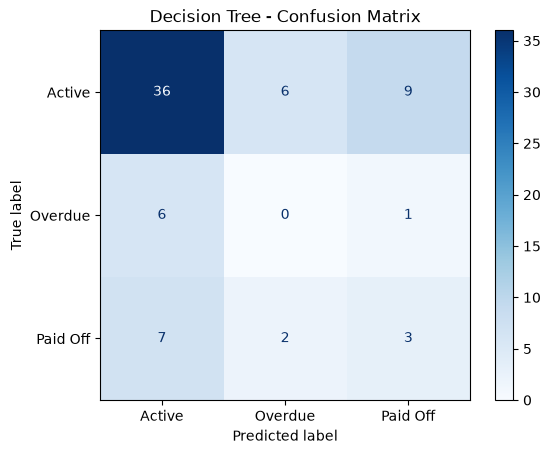

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    dt_model,
    x_test,
    y_test,
    display_labels=target_encoder.classes_,
    cmap="Blues"
)

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [60]:
print("Root Node Entropy:", dt_model.tree_.impurity[0])

Root Node Entropy: 1.1108501109870301


In [61]:
for i in range(dt_model.tree_.node_count):
    print(
        f"Node {i} -> Entropy: {dt_model.tree_.impurity[i]:.4f}"
    )

Node 0 -> Entropy: 1.1109
Node 1 -> Entropy: 0.7881
Node 2 -> Entropy: 0.7245
Node 3 -> Entropy: 1.3347
Node 4 -> Entropy: 0.9852
Node 5 -> Entropy: 0.0000
Node 6 -> Entropy: 0.0000
Node 7 -> Entropy: 0.9183
Node 8 -> Entropy: 0.9183
Node 9 -> Entropy: 0.0000
Node 10 -> Entropy: 0.0000
Node 11 -> Entropy: 0.0000
Node 12 -> Entropy: 0.4199
Node 13 -> Entropy: 0.1720
Node 14 -> Entropy: 0.0000
Node 15 -> Entropy: 0.8113
Node 16 -> Entropy: 0.0000
Node 17 -> Entropy: 0.0000
Node 18 -> Entropy: 0.9544
Node 19 -> Entropy: 0.8113
Node 20 -> Entropy: 0.0000
Node 21 -> Entropy: 0.0000
Node 22 -> Entropy: 0.0000
Node 23 -> Entropy: 0.0000
Node 24 -> Entropy: 1.1700
Node 25 -> Entropy: 1.2958
Node 26 -> Entropy: 0.8113
Node 27 -> Entropy: 0.0000
Node 28 -> Entropy: 0.9183
Node 29 -> Entropy: 0.0000
Node 30 -> Entropy: 0.0000
Node 31 -> Entropy: 0.6500
Node 32 -> Entropy: 0.0000
Node 33 -> Entropy: 0.0000
Node 34 -> Entropy: 1.1213
Node 35 -> Entropy: 1.1814
Node 36 -> Entropy: 1.2093
Node 37 -> 

In [62]:
from sklearn.tree import plot_tree

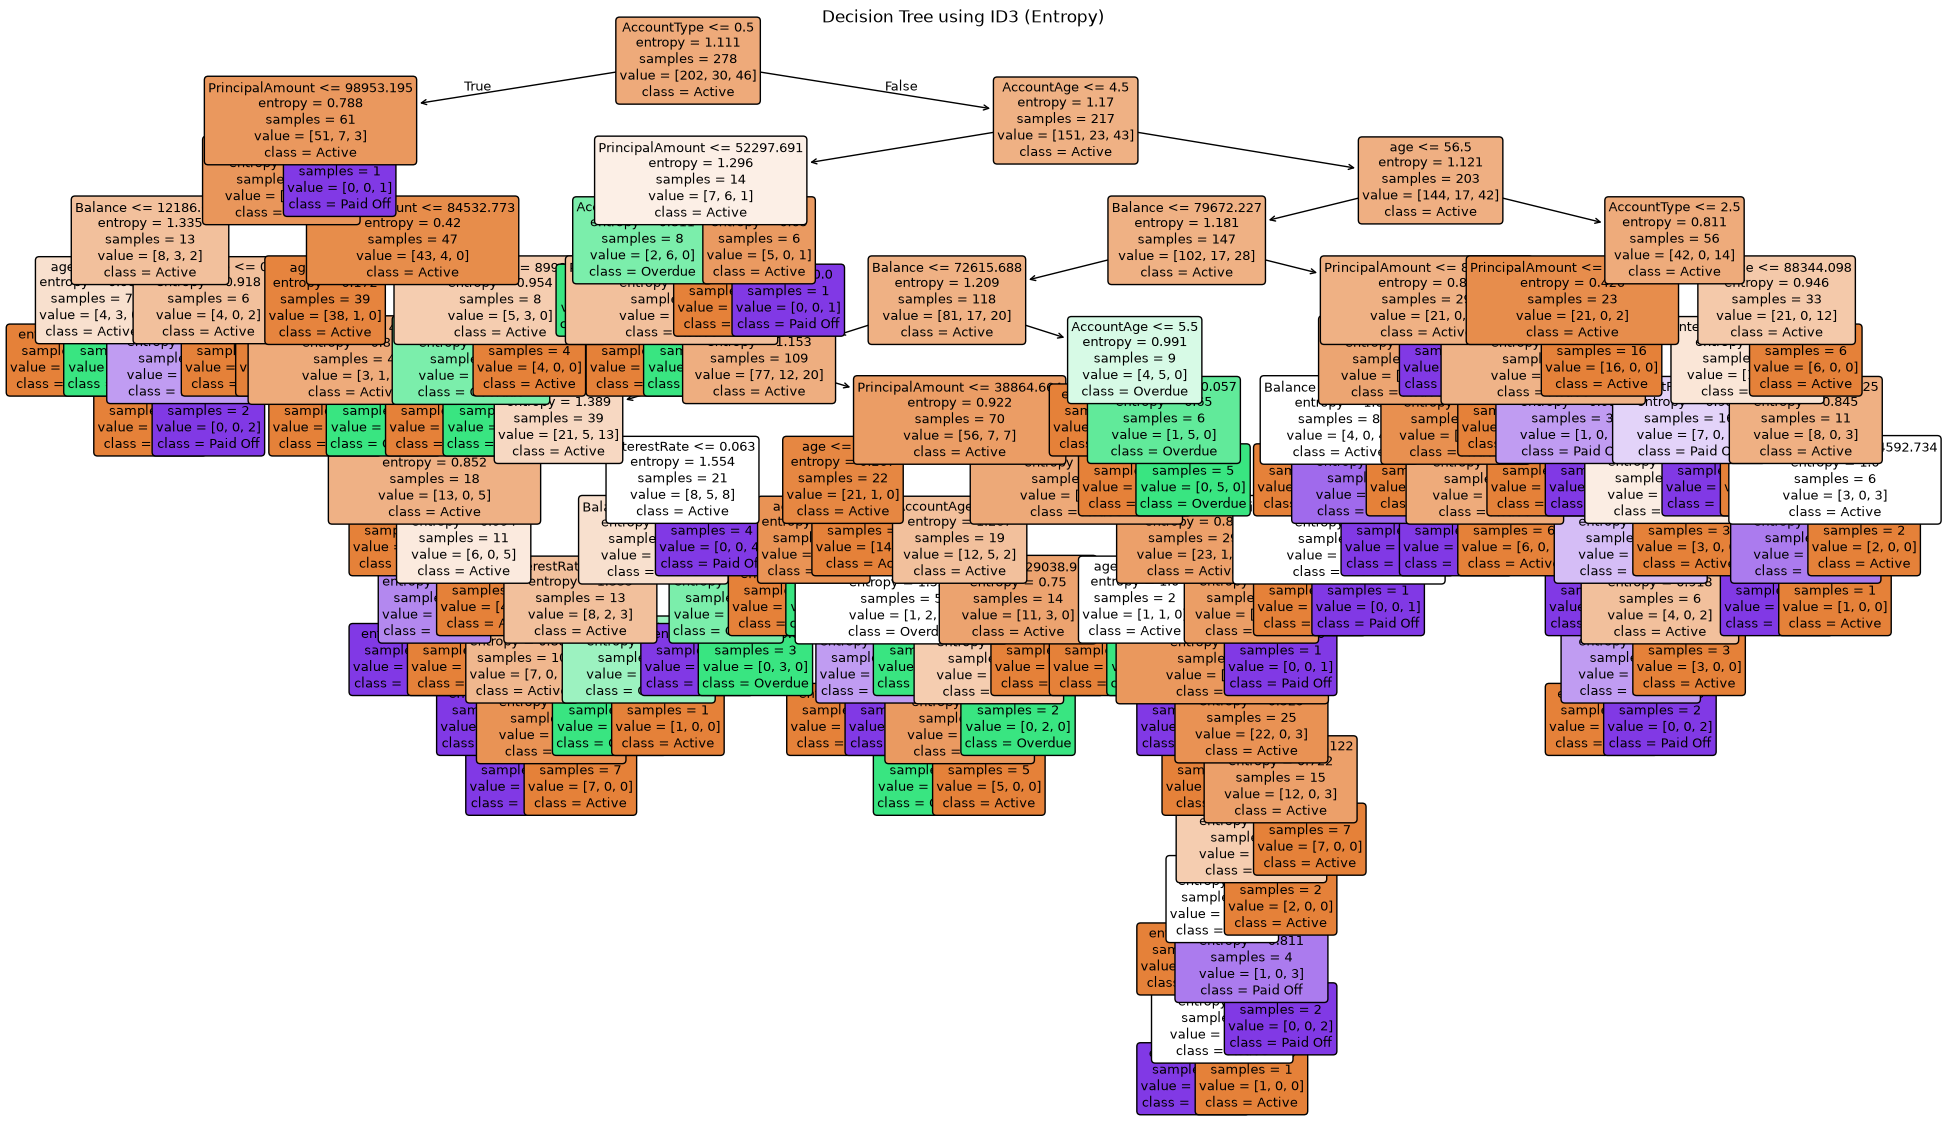

In [63]:
plt.figure(figsize=(24,14))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=target_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree using ID3 (Entropy)")
plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(Before moving to the Overfitting section, run these additional analyses and share:

    Training Accuracy

    Testing Accuracy

    Tree Depth

    Number of Leaf Nodes

    Feature Importance table

    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Balance,0.243831
6,PrincipalAmount,0.211908
7,InterestRate,0.183773
0,age,0.181732
5,AccountAge,0.086022
3,AccountType,0.057533
4,AccountStatus,0.020984
2,CustomerType,0.014217


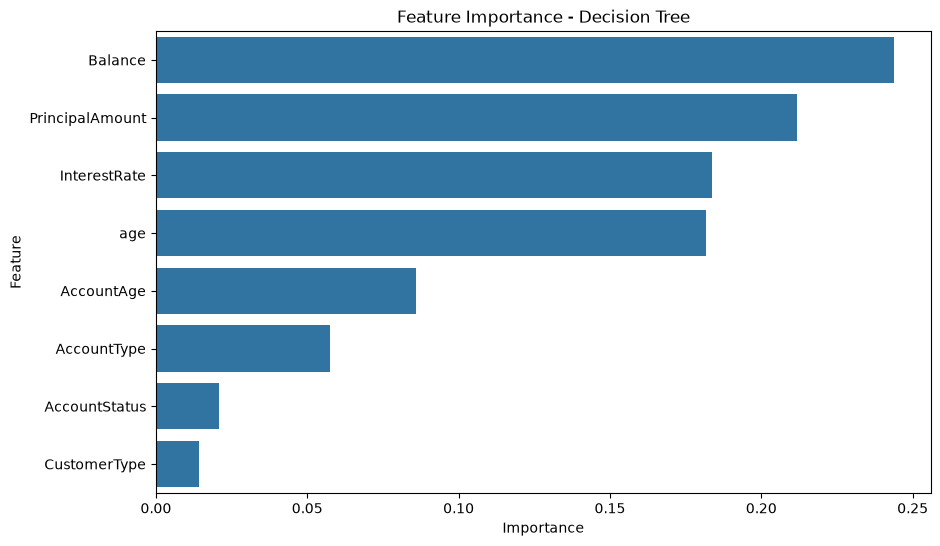

In [65]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Decision Tree")

plt.show()

In [66]:
print("Tree Depth :", dt_model.get_depth())

Tree Depth : 17


In [67]:
print("Leaf Nodes :", dt_model.get_n_leaves())


Leaf Nodes : 76


In [69]:
train_acc = dt_model.score(x_train, y_train)
test_acc = dt_model.score(x_test, y_test)

print(f"Training Accuracy : {train_acc:.2%}")
print(f"Testing Accuracy  : {test_acc:.2%}")

Training Accuracy : 100.00%
Testing Accuracy  : 55.71%


In [72]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

depths = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 17]

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=42
    )

    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append({
        "Max Depth": depth,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc
    })

results_df = pd.DataFrame(results)

results_df

,Max Depth,Train Accuracy,Test Accuracy
0,2,0.730216,0.742857
1,3,0.744604,0.728571
2,4,0.751799,0.742857
3,5,0.787770,0.700000
4,6,0.820144,0.685714
5,7,0.852518,0.685714
6,8,0.877698,0.657143
7,10,0.953237,0.585714
8,12,0.989209,0.585714
9,15,0.996403,0.557143


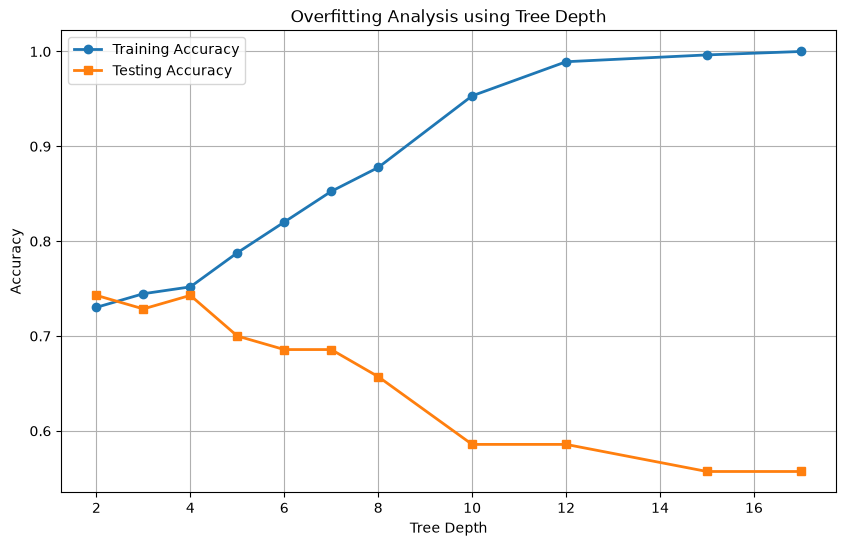

In [73]:
plt.figure(figsize=(10,6))

plt.plot(
    results_df["Max Depth"],
    results_df["Train Accuracy"],
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    results_df["Max Depth"],
    results_df["Test Accuracy"],
    marker="s",
    linewidth=2,
    label="Testing Accuracy"
)

plt.xlabel("Tree Depth")

plt.ylabel("Accuracy")

plt.title("Overfitting Analysis using Tree Depth")

plt.legend()

plt.grid(True)

plt.show()

In [74]:
best_model = results_df.loc[
    results_df["Test Accuracy"].idxmax()
]

best_model

Max Depth         2.000000
Train Accuracy    0.730216
Test Accuracy     0.742857
Name: 0, dtype: float64

In [91]:
best_depth = int(best_model["Max Depth"])

optimized_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=best_depth,
    random_state=42
)

new=optimized_tree.fit(x_train, y_train)

optimized_predictions = new.predict(x_test)

In [79]:
print("Best Depth:", best_depth)

print()

print(classification_report(
    y_test,
    optimized_predictions,
    target_names=target_encoder.classes_
))

Best Depth: 2

              precision    recall  f1-score   support

      Active       0.74      1.00      0.85        51
     Overdue       0.00      0.00      0.00         7
    Paid Off       1.00      0.08      0.15        12

    accuracy                           0.74        70
   macro avg       0.58      0.36      0.33        70
weighted avg       0.71      0.74      0.65        70



/home/student/Documents/308/mlm/.mlmlab/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/student/Documents/308/mlm/.mlmlab/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/student/Documents/308/mlm/.mlmlab/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

In [81]:
comparison = pd.DataFrame({

    "Model": [
        "Original Decision Tree",
        "Optimized Decision Tree"
    ],

    "Training Accuracy": [
        dt_model.score(x_train, y_train),
        optimized_tree.score(x_train, y_train)
    ],

    "Testing Accuracy": [
        dt_model.score(x_test, y_test),
        optimized_tree.score(x_test, y_test)
    ]

})

comparison

,Model,Training Accuracy,Testing Accuracy
0,Original Decision Tree,1.000000,0.557143
1,Optimized Decision Tree,0.730216,0.742857


In [92]:
import joblib

joblib.dump(
    new,
    "/home/student/Documents/308/mlm/AI-Banking-Financial-Intelligence-Platform/modules/decision_tree_id3.pkl"
)

print("Decision Tree model saved successfully.")

Decision Tree model saved successfully.


In [87]:
joblib.dump(
    label_encoders,
    "/home/student/Documents/308/mlm/AI-Banking-Financial-Intelligence-Platform/modules/feature_label_encoders.pkl"
)

joblib.dump(
    target_encoder,
    "/home/student/Documents/308/mlm/AI-Banking-Financial-Intelligence-Platform/modules/target_label_encoder.pkl"
)

print("Encoders saved successfully.")

Encoders saved successfully.


In [90]:
importance.to_csv(
    "/home/student/Documents/308/mlm/AI-Banking-Financial-Intelligence-Platform/modules/feature_importance.csv",
    index=False
)

In [ ]:
model_info = pd.DataFrame({
    "Metric": [
        "Algorithm",
        "Criterion",
        "Tree Depth",
        "Leaf Nodes",
        "Training Accuracy",
        "Testing Accuracy",
        "Root Entropy"
    ],
    "Value": [
        "Decision Tree",
        "Entropy (ID3)",
        dt_model.get_depth(),
        dt_model.get_n_leaves(),
        dt_model.score(x_train, y_train),
        dt_model.score(X_test, y_test),
        dt_model.tree_.impurity[0]
    ]
})

model_info.to_csv(
    "../reports/model_summary.csv",
    index=False
)

model_info